### Drought characterstics such as frequency and average duration and impact on hydropower generation

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
from matplotlib.gridspec import GridSpec


# Set publication-quality style parameters
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 600
})


In [4]:
#### Global hybrid model predicted data
input_global_dir = "/scratch/shah0012/hybrid_hydropower_model/hybrid_model_results/"
input_global_data = pd.read_csv(input_global_dir + "global_data_prediction_designed_dataset_drought_attributes_included_1982_2022_target_CF.csv", parse_dates=["date"])

glohydrores_file = "/home/shah0012/GloHydroRes/Output_data/GloHydroRes_vs2.xlsx"
glohydrores_df = pd.read_excel(glohydrores_file, sheet_name="Data")    
input_global_data["country"] = input_global_data.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["country"])))
input_global_data["plant_type"] = input_global_data.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["plant_type"])))
input_global_data["month"] = input_global_data.date.dt.month

# Here using 20 percentile threshold and at least 3 consecutive duration of drought
input_global_data["drought_indicator"] = (input_global_data.drought_20_pooled_3length > 0).astype(int)

In [17]:
long_term_mean = input_global_data.groupby(["month", "glohydrores_plant_id"])["originial_prediction"].mean().reset_index()
long_term_mean.rename(columns = {"originial_prediction" : "long_term_mean_prediction"}, inplace = True)

#### Frequency of droughts on each hydropower plant

In [7]:
drought_counts = input_global_data.groupby(["glohydrores_plant_id"])["drought_20_pooled_3length"].nunique().reset_index()
drought_counts["drought_20_pooled_3length"] = drought_counts.drought_20_pooled_3length - 1 #As 0 will also going to count as unique drought
drought_counts["plant_type"]  =  drought_counts.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["plant_type"])))
drought_counts["plant_lat"]  =  drought_counts.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["plant_lat"])))
drought_counts["plant_lon"]  =  drought_counts.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["plant_lon"])))

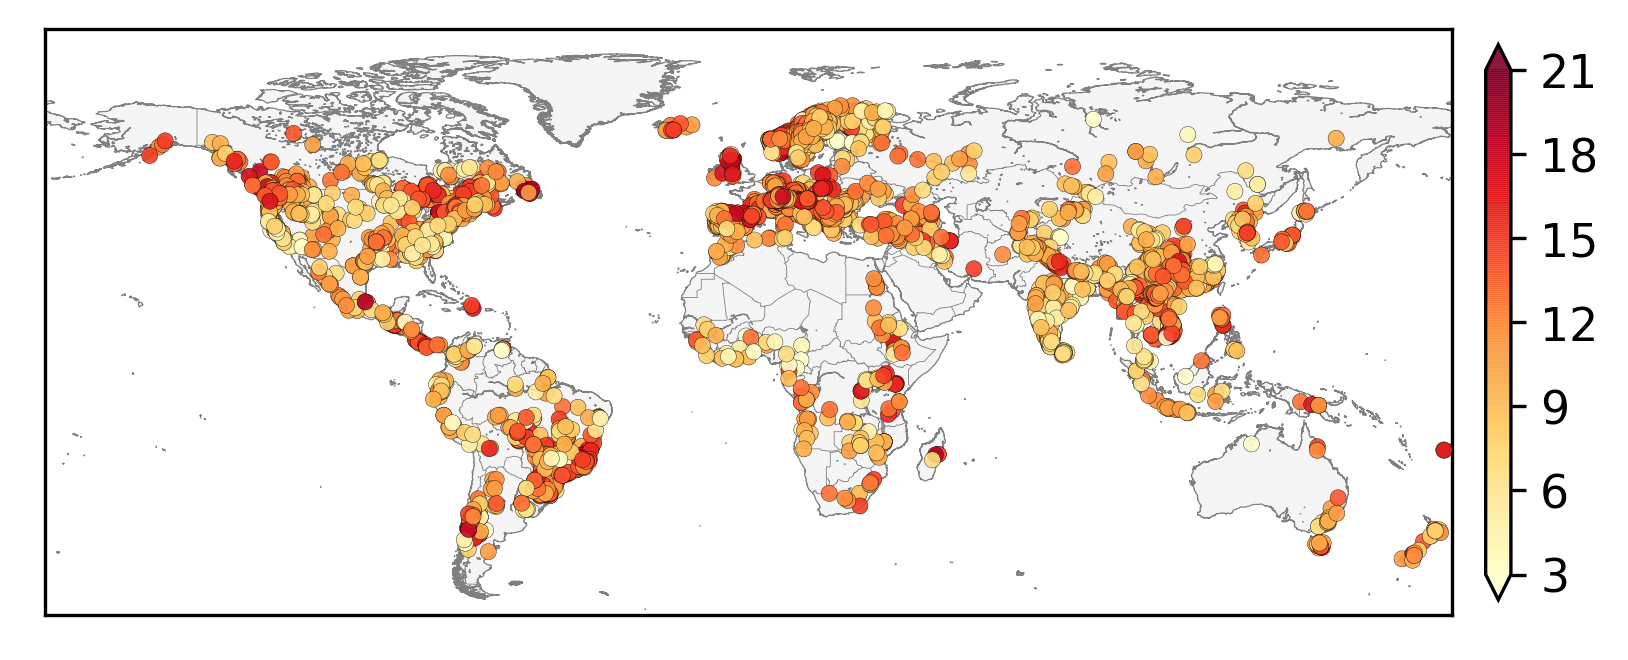

In [ ]:
plant_lat = drought_counts.plant_lat.values
plant_lon = drought_counts.plant_lon.values
drought_length = drought_counts.drought_20_pooled_3length.values



from matplotlib.colors import BoundaryNorm
from matplotlib import cm

# Create figure with GridSpec
fig = plt.figure(figsize=(6, 4), dpi=300)
gs = GridSpec(1, 1)

#original size = (7, 4)
# First plot - All hydropower plants
ax1 = fig.add_subplot(gs[0])
m1 = Basemap(
    projection='cyl',
    llcrnrlat=-60,
    urcrnrlat=90,
    llcrnrlon=-180,
    urcrnrlon=180,
    resolution='i',
    ax=ax1
)

m1.drawcoastlines(linewidth=0.3, color='gray')
m1.fillcontinents(color="whitesmoke", lake_color='white', zorder=1)
m1.drawcountries(linewidth=0.2, color='gray')



boundaries = np.arange(3, 24, 3)


# Plot points
sc1 = ax1.scatter(
    plant_lon, plant_lat,
    c=drought_length,
    zorder=5,
    s = 15,
    alpha=0.9,
    edgecolors='black',
    linewidth=0.1, 
    cmap="YlOrRd",
     vmin=3, vmax=21
)

cbar = plt.colorbar(sc1, ax=ax1, orientation="vertical", pad=0.02, 
                    shrink=0.5, extend="both", spacing='proportional')
cbar.set_ticks(boundaries)
cbar.ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig("/home/shah0012/Hydropower_hybrid_model/figures/number_drought_events.png", dpi=600, bbox_inches='tight')
plt.show()

#### Average drought duration

In [10]:
input_global_data['drought_length']  = (
    input_global_data.groupby(['glohydrores_plant_id', 'drought_20_pooled_3length'])['drought_20_pooled_3length']
      .transform('count')
)

input_global_data.loc[input_global_data.drought_indicator == 0, "drought_length"] = 0

average_length_each_plant = (input_global_data.groupby("glohydrores_plant_id")["drought_length"]
.apply(lambda x : x[x>0].mean()).reset_index()
)

average_length_each_plant["plant_type"]  =  average_length_each_plant.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["plant_type"])))
average_length_each_plant["plant_lat"]  =  average_length_each_plant.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["plant_lat"])))
average_length_each_plant["plant_lon"]  =  average_length_each_plant.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["plant_lon"])))


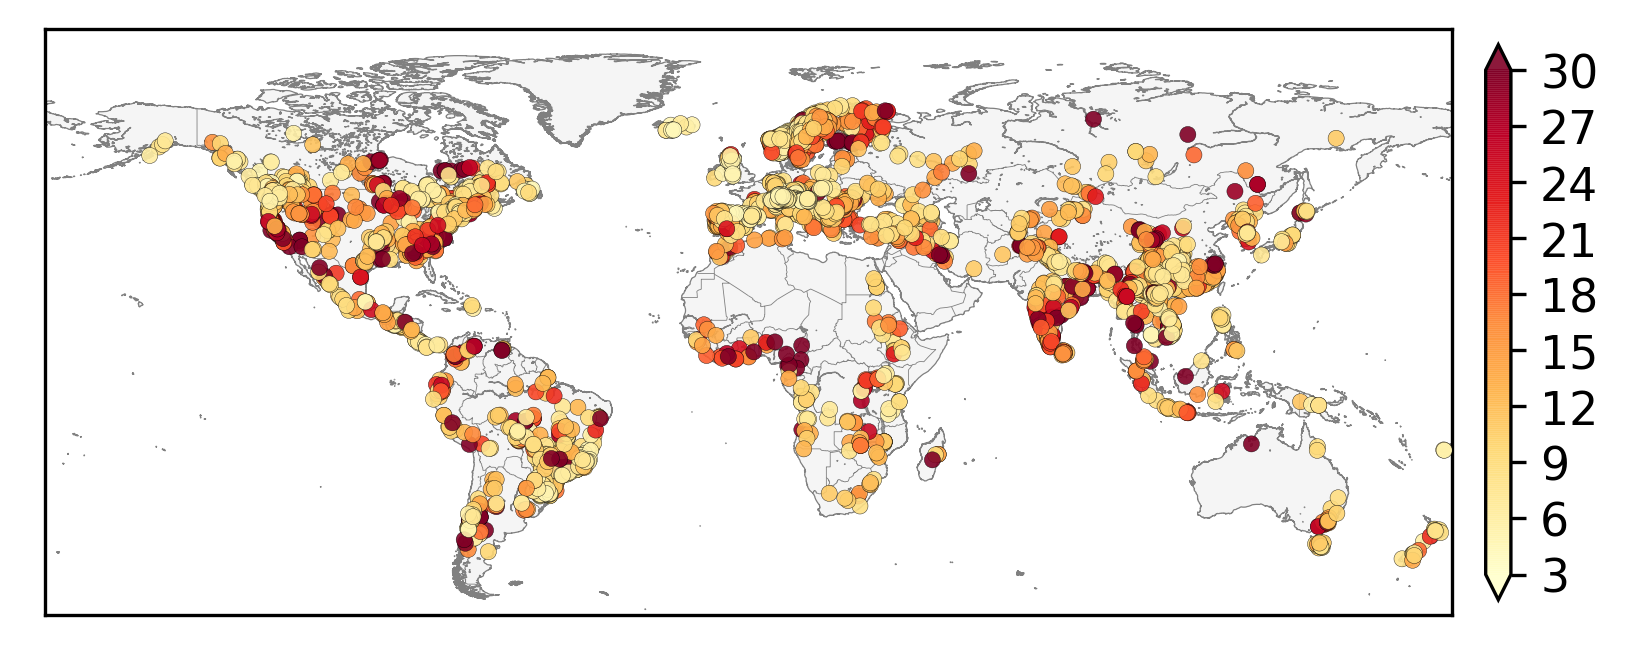

In [ ]:
plant_lat = average_length_each_plant.plant_lat.values
plant_lon = average_length_each_plant.plant_lon.values
drought_length = average_length_each_plant.drought_length.values



from matplotlib.colors import BoundaryNorm
from matplotlib import cm

# Create figure with GridSpec
fig = plt.figure(figsize=(6, 4), dpi=300)
gs = GridSpec(1, 1)


# First plot - All hydropower plants
ax1 = fig.add_subplot(gs[0])
m1 = Basemap(
    projection='cyl',
    llcrnrlat=-60,
    urcrnrlat=90,
    llcrnrlon=-180,
    urcrnrlon=180,
    resolution='i',
    ax=ax1
)

m1.drawcoastlines(linewidth=0.3, color='gray')
m1.fillcontinents(color="whitesmoke", lake_color='white', zorder=1)
m1.drawcountries(linewidth=0.2, color='gray')

# Define discrete boundaries
boundaries = np.arange(3, 33, 3)

# Plot points
sc1 = ax1.scatter(
    plant_lon, plant_lat,
    c=drought_length,
    zorder=5,
    s = 15,
    alpha=0.9,
    edgecolors='black',
    linewidth=0.1, 
    cmap="YlOrRd",
    vmin = 3, vmax = 30
)

cbar = plt.colorbar(sc1, ax=ax1, orientation="vertical", pad=0.02, 
                    shrink=0.5, extend="both", spacing='proportional')
cbar.set_ticks(boundaries)
cbar.ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig("/home/shah0012/Hydropower_hybrid_model/figures/average_drought_length.png", dpi=600, bbox_inches='tight')
plt.show()

#### Average reduction in hydropower generation during drought

In [ ]:
# As drought indicators have 0 as non drought and 1 as drought hence this will average of all 0s and 1s of each hydropower plant and month separately
monthly_average_prediction_drought_nondrought = input_global_data.groupby(["month", "glohydrores_plant_id", "drought_indicator"])["originial_prediction"].mean().reset_index()
monthly_average_prediction_drought_nondrought = monthly_average_prediction_drought_nondrought.merge(long_term_mean, on = ["month", "glohydrores_plant_id"], how = "left")
monthly_average_prediction_drought_nondrought.rename(columns = {"originial_prediction" : "monthly_mean_prediction"}, inplace = True)

monthly_average_prediction_drought_nondrought = monthly_average_prediction_drought_nondrought.pivot_table(
    index=["glohydrores_plant_id", "month", "long_term_mean_prediction"],
    columns="drought_indicator",
    values="monthly_mean_prediction"
).reset_index()

monthly_average_prediction_drought_nondrought.rename(columns = {0 : "non_drought_monthly_generation", 1 : "drought_monthly_generation"}, inplace = True)
monthly_average_prediction_drought_nondrought["deviation_longterm"] = (monthly_average_prediction_drought_nondrought.drought_monthly_generation - monthly_average_prediction_drought_nondrought.long_term_mean_prediction)/(monthly_average_prediction_drought_nondrought.long_term_mean_prediction)
monthly_average_prediction_drought_nondrought["deviation_longterm"] = monthly_average_prediction_drought_nondrought.deviation_longterm*100

overall_reduction =  monthly_average_prediction_drought_nondrought.groupby("glohydrores_plant_id")["deviation_longterm"].mean().reset_index()
overall_reduction["plant_type"]  =  overall_reduction.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["plant_type"])))
overall_reduction["plant_lat"]  =  overall_reduction.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["plant_lat"])))
overall_reduction["plant_lon"]  =  overall_reduction.glohydrores_plant_id.map(dict(zip(glohydrores_df["ID"], glohydrores_df["plant_lon"])))

overall_reduction["plant_type"] = overall_reduction.plant_type.fillna("STO")
plant_lat = overall_reduction.plant_lat.values
plant_lon = overall_reduction.plant_lon.values
reduction_in_generation =  overall_reduction.deviation_longterm.values

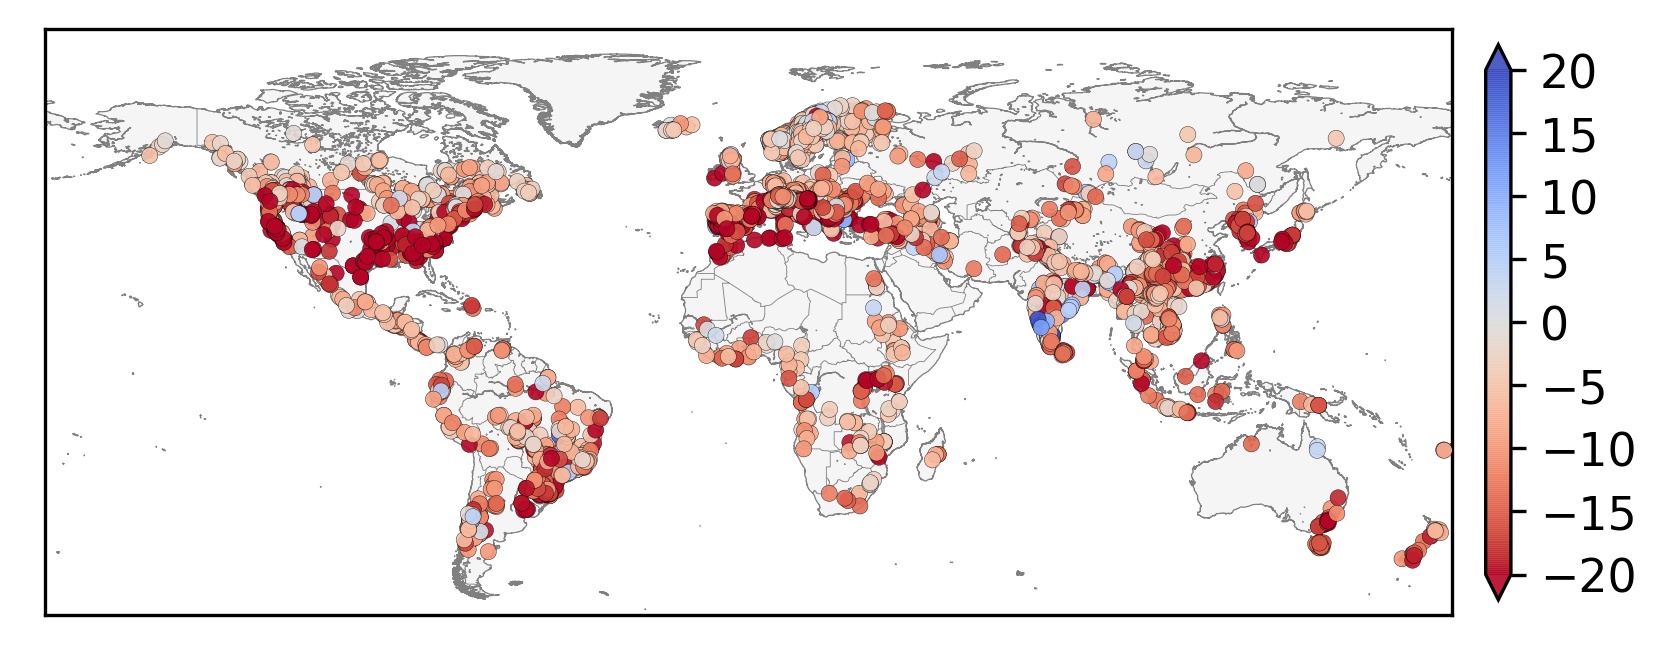

In [ ]:
unique_plant_type = overall_reduction.plant_type.unique()
from matplotlib.colors import BoundaryNorm
from matplotlib import cm

# Create figure with GridSpec
fig = plt.figure(figsize=(6, 4), dpi=300)
gs = GridSpec(1, 1)

#original size (7,4)

# First plot - All hydropower plants
ax1 = fig.add_subplot(gs[0])
m1 = Basemap(
    projection='cyl',
    llcrnrlat=-60,
    urcrnrlat=90,
    llcrnrlon=-180,
    urcrnrlon=180,
    resolution='i',
    ax=ax1
)

m1.drawcoastlines(linewidth=0.3, color='gray')
m1.fillcontinents(color="whitesmoke", lake_color='white', zorder=1)
m1.drawcountries(linewidth=0.2, color='gray')

# Define discrete boundaries
boundaries = np.arange(-20, 25, 5)
norm = BoundaryNorm(boundaries, cm.RdYlBu.N, clip=True)

sc1 = ax1.scatter(
    plant_lon, plant_lat,
    c=reduction_in_generation,
    zorder=5,
    s = 15,
    alpha=0.9,
    edgecolors='black',
    linewidth=0.1, 
    cmap="coolwarm_r",
    vmin = -20, vmax = 20
)


cbar = plt.colorbar(sc1, ax=ax1, orientation="vertical", pad=0.02, 
                    shrink=0.5, extend="both", spacing='proportional')
cbar.set_ticks(boundaries)
cbar.ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig("/home/shah0012/Hydropower_hybrid_model/figures/average_generation_reduction.png",dpi=600, bbox_inches='tight')
plt.savefig("/home/shah0012/Hydropower_hybrid_model/figures/average_generation_reduction.pdf",dpi=300, bbox_inches='tight')
plt.show()

#### Heatmap showing average reduction with binned using average drought duration and installed capacity

In [ ]:
input_global_data = input_global_data.merge(long_term_mean, on = ["glohydrores_plant_id", "month"], how = "left")
input_global_data["deviation_longterm"] = ((input_global_data.originial_prediction - input_global_data.long_term_mean_prediction)/(input_global_data.long_term_mean_prediction))*100
average_deviation_each_drought = input_global_data.groupby(["glohydrores_plant_id", "drought_20_pooled_3length"])["deviation_longterm"].mean().reset_index()
average_deviation_each_drought = average_deviation_each_drought[average_deviation_each_drought.drought_20_pooled_3length != 0]
average_deviation_each_drought  = average_deviation_each_drought.merge(input_global_data[["glohydrores_plant_id", "drought_20_pooled_3length", "drought_length"]], on = ["glohydrores_plant_id", "drought_20_pooled_3length"], how = "left")
average_deviation_each_drought.drop_duplicates(subset = ["glohydrores_plant_id", "drought_20_pooled_3length"], inplace = True)
average_deviation_each_drought["installed_cap"] = average_deviation_each_drought.glohydrores_plant_id.map(dict(zip(glohydrores_df.ID, glohydrores_df.capacity_mw)))

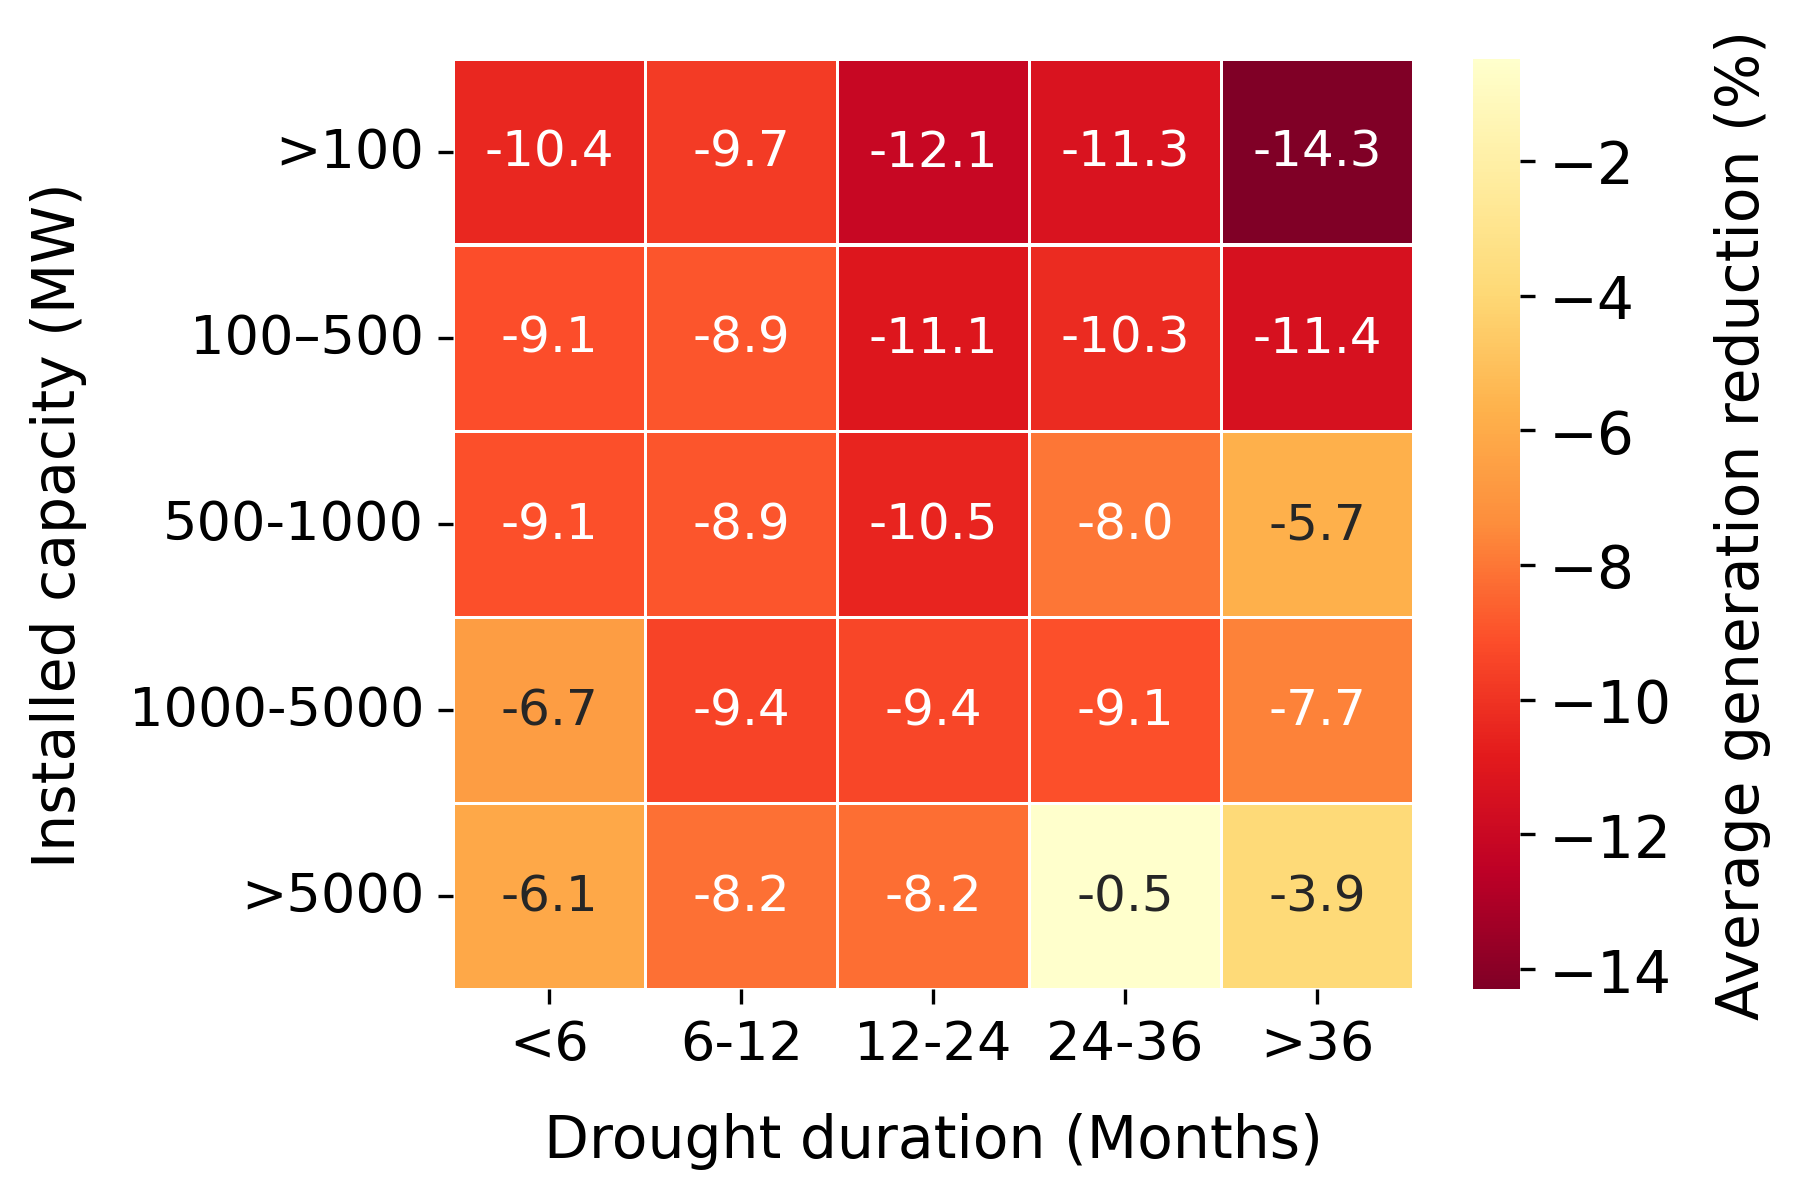

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


capacity_bins = [0, 100, 500, 1000, 5000, average_deviation_each_drought['installed_cap'].max()]
capacity_labels = ['>100',  '100–500', '500-1000', '1000-5000', '>5000']



# Based on drought severity classifications
length_bins = [0, 6, 12, 24, 36,
               average_deviation_each_drought['drought_length'].max()]
length_labels = ['<6', '6-12', 
                 '12-24', '24-36', '>36']

# Apply binning
average_deviation_each_drought['capacity_class'] = pd.cut(average_deviation_each_drought['installed_cap'], bins=capacity_bins, labels=capacity_labels, include_lowest=True)
average_deviation_each_drought['length_class'] = pd.cut(average_deviation_each_drought['drought_length'], bins=length_bins, labels=length_labels, include_lowest=True)


heatmap_data = (
    average_deviation_each_drought.groupby(['capacity_class', 'length_class'])['deviation_longterm']
      .mean()
      .unstack()
)

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)


# Plot
sns.heatmap(heatmap_data, cmap='YlOrRd_r', annot=True, fmt=".1f", ax = ax, linecolor = "white", linewidths = 0.5, square = False, annot_kws={'size': 12})
ax.set_xlabel('Drought duration (Months)', fontsize = 14,  labelpad = 10)
ax.set_ylabel('Installed capacity (MW)', fontsize = 14,  labelpad = 10)
ax.tick_params(labelsize=13)
#ax.set_title('Average Reduction (%) by Drought Length and Installed Capacity')
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize = 14)
cbar.set_label("Average generation reduction (%)", fontsize = 14, labelpad = 10)

plt.tight_layout()
plt.savefig('/home/shah0012/Hydropower_hybrid_model/figures/heatmap_drought_reduction_installed_cap_drought_length.png', dpi = 600, bbox_inches='tight')  # Vector format

plt.show()